In [1]:
#MLP
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from skimage.feature import hog
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Define function to extract HOG features
def extract_hog_features(images):
    hog_features = []
    for image in images:
        # Convert image to grayscale
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        # Compute HOG features
        features = hog(gray, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), transform_sqrt=True, block_norm="L2-Hys")
        hog_features.append(features)
    return np.array(hog_features)

# Load dataset and labels
def load_data(train_path, val_path, test_path):
    train_images, train_labels = load_images_from_path(train_path)
    val_images, val_labels = load_images_from_path(val_path)
    test_images, test_labels = load_images_from_path(test_path)
    return (train_images, train_labels), (val_images, val_labels), (test_images, test_labels)

def load_images_from_path(path):
    images = []
    labels = []
    for label in os.listdir(path):
        label_path = os.path.join(path, label)
        for filename in os.listdir(label_path):
            image_path = os.path.join(label_path, filename)
            # Load image
            image = cv2.imread(image_path)
            if image is not None:
                # Resize image to 224x224
                image = cv2.resize(image, (224, 224))
                images.append(image)
                labels.append(label)
            else:
                print("Error loading image:", image_path)
    return np.array(images), np.array(labels)

# Load dataset
train_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/train"
val_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/val"
test_path = "/kaggle/input/bonewithout-augment-70-20-10/boneWithOut_Augment/test"
(train_images, train_labels), (val_images, val_labels), (test_images, test_labels) = load_data(train_path, val_path, test_path)

# Split dataset into training, validation, and testing sets
X_train, y_train = train_images, train_labels
X_val, y_val = val_images, val_labels
X_test, y_test = test_images, test_labels

# Assuming train_images, train_labels, val_images, val_labels, test_images, and test_labels are numpy arrays or lists/tuples
print("Shape of training images:", X_train.shape)
print("Shape of training labels:", y_train.shape)
print("Shape of validation images:", X_val.shape)
print("Shape of validation labels:", y_val.shape)
print("Shape of test images:", X_test.shape)
print("Shape of test labels:", y_test.shape)

# Extract HOG features
X_train_hog = extract_hog_features(X_train)
X_val_hog = extract_hog_features(X_val)
X_test_hog = extract_hog_features(X_test)


from sklearn.decomposition import PCA

# Perform PCA on training, validation, and testing sets
pca = PCA()  # You can adjust the number of components as needed
X_train_pca = pca.fit_transform(X_train_hog)
X_val_pca = pca.transform(X_val_hog)
X_test_pca = pca.transform(X_test_hog)

# Manually specify class labels
class_labels = ['Abnormal', 'Normal']
from sklearn.preprocessing import LabelEncoder
# Encode labels
label_encoder = LabelEncoder()
label_encoder.fit(class_labels)

# Transform target labels
y_train_encoded = label_encoder.transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)


Shape of training images: (712, 224, 224, 3)
Shape of training labels: (712,)
Shape of validation images: (203, 224, 224, 3)
Shape of validation labels: (203,)
Shape of test images: (103, 224, 224, 3)
Shape of test labels: (103,)


In [2]:
# Assuming train_images is a list of images
train_hog_features = extract_hog_features(train_images)

# Print the shape of the extracted HOG features
print("Shape of extracted HOG features:", train_hog_features.shape)

import pandas as pd

# Combine HOG features and labels into a DataFrame
train_df = pd.DataFrame(data=X_train_pca, columns=[f'feature_{i}' for i in range(X_train_pca.shape[1])])
train_df['label'] = y_train_encoded

val_df = pd.DataFrame(data=X_val_pca, columns=[f'feature_{i}' for i in range(X_val_pca.shape[1])])
val_df['label'] = y_val_encoded

test_df = pd.DataFrame(data=X_test_pca, columns=[f'feature_{i}' for i in range(X_test_pca.shape[1])])
test_df['label'] = y_test_encoded

# Display the first few rows of the training DataFrame
print("Training DataFrame:")
print(train_df.head())

# Display the first few rows of the validation DataFrame
print("\nValidation DataFrame:")
print(val_df.head())

# Display the first few rows of the testing DataFrame
print("\nTesting DataFrame:")
print(test_df.head())


Shape of extracted HOG features: (712, 26244)
Training DataFrame:
   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0   4.560170   0.039662  -0.143604   1.599359  -0.143682  -4.295417   
1  -1.897059  -0.708479   1.309161   3.958441  -3.037891  -0.680293   
2  -2.842910  -3.595653   0.804719   0.635176   0.374949   0.112512   
3   2.792504  -2.575474   1.767418  -1.315502   0.593159   1.945346   
4   4.091954   1.197629  -0.889692  -0.434313   1.190078  -2.547413   

   feature_6  feature_7  feature_8  feature_9  ...   feature_703  \
0   0.927303   0.694360   0.966327   0.897890  ...  1.707295e-19   
1  -2.484125   1.167838  -1.862790  -0.304383  ...  1.707295e-19   
2   0.208111   0.865833   3.050581  -0.706242  ...  1.707295e-19   
3  -0.877121  -1.170020  -0.001763   1.046095  ...  1.707295e-19   
4  -0.548519  -1.691286   0.042528   0.870226  ...  1.707295e-19   

    feature_704   feature_705   feature_706   feature_707   feature_708  \
0  1.263379e-19  3.1587

In [3]:
from sklearn.neighbors import KNeighborsClassifier

# Initialize KNN classifier
knn_classifier = KNeighborsClassifier()

# Train the classifier
knn_classifier.fit(X_train_pca, y_train_encoded)#X_train_pca #X_train_hog

# Make predictions on validation set
val_predictions_knn = knn_classifier.predict(X_val_pca)# X_val_pca # X_val_hog

# Calculate accuracy on validation set
val_accuracy_knn = accuracy_score(y_val_encoded, val_predictions_knn)
print("Validation Accuracy (KNN):", val_accuracy_knn)

# Make predictions on test set
test_predictions_knn = knn_classifier.predict(X_test_pca) #X_test_pca #X_test_hog

# Calculate accuracy on test set
test_accuracy_knn = accuracy_score(y_test_encoded, test_predictions_knn)
print("Test Accuracy (KNN):", test_accuracy_knn)

# Calculate evaluation metrics for KNN classifier
val_precision_knn = precision_score(y_val_encoded, val_predictions_knn)
val_recall_knn = recall_score(y_val_encoded, val_predictions_knn)
val_f1_knn = f1_score(y_val_encoded, val_predictions_knn)
val_cm_knn = confusion_matrix(y_val_encoded, val_predictions_knn)

test_precision_knn = precision_score(y_test_encoded, test_predictions_knn)
test_recall_knn = recall_score(y_test_encoded, test_predictions_knn)
test_f1_knn = f1_score(y_test_encoded, test_predictions_knn)
test_cm_knn = confusion_matrix(y_test_encoded, test_predictions_knn)

# Print validation metrics for KNN classifier
print("\nValidation Metrics (KNN):")
print("Precision:", val_precision_knn)
print("Recall:", val_recall_knn)
print("F1 Score:", val_f1_knn)
print("Confusion Matrix:")
print(val_cm_knn)

# Print classification report for KNN classifier on validation set
print("\nValidation Classification Report (KNN):")
print(classification_report(y_val_encoded, val_predictions_knn, target_names=class_labels))

# Print test metrics for KNN classifier
print("\nTest Metrics (KNN):")
print("Precision:", test_precision_knn)
print("Recall:", test_recall_knn)
print("F1 Score:", test_f1_knn)
print("Confusion Matrix:")
print(test_cm_knn)

# Print classification report for KNN classifier on test set
print("\nTest Classification Report (KNN):")
print(classification_report(y_test_encoded, test_predictions_knn, target_names=class_labels))


Validation Accuracy (KNN): 0.8078817733990148
Test Accuracy (KNN): 0.8058252427184466

Validation Metrics (KNN):
Precision: 0.7407407407407407
Recall: 0.8791208791208791
F1 Score: 0.8040201005025126
Confusion Matrix:
[[84 28]
 [11 80]]

Validation Classification Report (KNN):
              precision    recall  f1-score   support

    Abnormal       0.88      0.75      0.81       112
      Normal       0.74      0.88      0.80        91

    accuracy                           0.81       203
   macro avg       0.81      0.81      0.81       203
weighted avg       0.82      0.81      0.81       203


Test Metrics (KNN):
Precision: 0.7288135593220338
Recall: 0.9148936170212766
F1 Score: 0.8113207547169811
Confusion Matrix:
[[40 16]
 [ 4 43]]

Test Classification Report (KNN):
              precision    recall  f1-score   support

    Abnormal       0.91      0.71      0.80        56
      Normal       0.73      0.91      0.81        47

    accuracy                           0.81       103

* Accuracy ≈ 0.8058
* Precision ≈ 0.7288
* Recall ≈ 0.9149
* F1 Score ≈ 0.8112

In [4]:
from sklearn.svm import SVC

# Initialize SVM classifier
svm_classifier = SVC(random_state=42)

# Train the classifier
svm_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_svm = svm_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_svm = accuracy_score(y_val_encoded, val_predictions_svm)
print("Validation Accuracy (SVM):", val_accuracy_svm)

# Make predictions on test set
test_predictions_svm = svm_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_svm = accuracy_score(y_test_encoded, test_predictions_svm)
print("Test Accuracy (SVM):", test_accuracy_svm)

# Calculate evaluation metrics for SVM classifier
val_precision_svm = precision_score(y_val_encoded, val_predictions_svm)
val_recall_svm = recall_score(y_val_encoded, val_predictions_svm)
val_f1_svm = f1_score(y_val_encoded, val_predictions_svm)
val_cm_svm = confusion_matrix(y_val_encoded, val_predictions_svm)

test_precision_svm = precision_score(y_test_encoded, test_predictions_svm)
test_recall_svm = recall_score(y_test_encoded, test_predictions_svm)
test_f1_svm = f1_score(y_test_encoded, test_predictions_svm)
test_cm_svm = confusion_matrix(y_test_encoded, test_predictions_svm)

# Print validation metrics for SVM classifier
print("\nValidation Metrics (SVM):")
print("Precision:", val_precision_svm)
print("Recall:", val_recall_svm)
print("F1 Score:", val_f1_svm)
print("Confusion Matrix:")
print(val_cm_svm)

# Print classification report for SVM classifier on validation set
print("\nValidation Classification Report (SVM):")
print(classification_report(y_val_encoded, val_predictions_svm, target_names=class_labels))

# Print test metrics for SVM classifier
print("\nTest Metrics (SVM):")
print("Precision:", test_precision_svm)
print("Recall:", test_recall_svm)
print("F1 Score:", test_f1_svm)
print("Confusion Matrix:")
print(test_cm_svm)

# Print classification report for SVM classifier on test set
print("\nTest Classification Report (SVM):")
print(classification_report(y_test_encoded, test_predictions_svm, target_names=class_labels))


Validation Accuracy (SVM): 0.8571428571428571
Test Accuracy (SVM): 0.8252427184466019

Validation Metrics (SVM):
Precision: 0.7980769230769231
Recall: 0.9120879120879121
F1 Score: 0.8512820512820513
Confusion Matrix:
[[91 21]
 [ 8 83]]

Validation Classification Report (SVM):
              precision    recall  f1-score   support

    Abnormal       0.92      0.81      0.86       112
      Normal       0.80      0.91      0.85        91

    accuracy                           0.86       203
   macro avg       0.86      0.86      0.86       203
weighted avg       0.86      0.86      0.86       203


Test Metrics (SVM):
Precision: 0.7636363636363637
Recall: 0.8936170212765957
F1 Score: 0.8235294117647058
Confusion Matrix:
[[43 13]
 [ 5 42]]

Test Classification Report (SVM):
              precision    recall  f1-score   support

    Abnormal       0.90      0.77      0.83        56
      Normal       0.76      0.89      0.82        47

    accuracy                           0.83       103

* Accuracy ≈ 0.8252
* Precision ≈ 0.7636
* Recall ≈ 0.8936
* F1 Score ≈ 0.8235

In [5]:

from sklearn.linear_model import PassiveAggressiveClassifier

# Initialize Passive-Aggressive Classifier
pac_classifier = PassiveAggressiveClassifier(random_state=42)

# Train the classifier
pac_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_pac = pac_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_pac = accuracy_score(y_val_encoded, val_predictions_pac)
print("Validation Accuracy (Passive-Aggressive Classifier):", val_accuracy_pac)

# Make predictions on test set
test_predictions_pac = pac_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_pac = accuracy_score(y_test_encoded, test_predictions_pac)
print("Test Accuracy (Passive-Aggressive Classifier):", test_accuracy_pac)

# Calculate evaluation metrics for Passive-Aggressive Classifier
val_precision_pac = precision_score(y_val_encoded, val_predictions_pac)
val_recall_pac = recall_score(y_val_encoded, val_predictions_pac)
val_f1_pac = f1_score(y_val_encoded, val_predictions_pac)
val_cm_pac = confusion_matrix(y_val_encoded, val_predictions_pac)

test_precision_pac = precision_score(y_test_encoded, test_predictions_pac)
test_recall_pac = recall_score(y_test_encoded, test_predictions_pac)
test_f1_pac = f1_score(y_test_encoded, test_predictions_pac)
test_cm_pac = confusion_matrix(y_test_encoded, test_predictions_pac)

# Print validation metrics for Passive-Aggressive Classifier
print("\nValidation Metrics (Passive-Aggressive Classifier):")
print("Precision:", val_precision_pac)
print("Recall:", val_recall_pac)
print("F1 Score:", val_f1_pac)
print("Confusion Matrix:")
print(val_cm_pac)

# Print classification report for Passive-Aggressive Classifier on validation set
print("\nValidation Classification Report (Passive-Aggressive Classifier):")
print(classification_report(y_val_encoded, val_predictions_pac, target_names=class_labels))

# Print test metrics for Passive-Aggressive Classifier
print("\nTest Metrics (Passive-Aggressive Classifier):")
print("Precision:", test_precision_pac)
print("Recall:", test_recall_pac)
print("F1 Score:", test_f1_pac)
print("Confusion Matrix:")
print(test_cm_pac)

# Print classification report for Passive-Aggressive Classifier on test set
print("\nTest Classification Report (Passive-Aggressive Classifier):")
print(classification_report(y_test_encoded, test_predictions_pac, target_names=class_labels))


Validation Accuracy (Passive-Aggressive Classifier): 0.9064039408866995
Test Accuracy (Passive-Aggressive Classifier): 0.912621359223301

Validation Metrics (Passive-Aggressive Classifier):
Precision: 0.9390243902439024
Recall: 0.8461538461538461
F1 Score: 0.8901734104046243
Confusion Matrix:
[[107   5]
 [ 14  77]]

Validation Classification Report (Passive-Aggressive Classifier):
              precision    recall  f1-score   support

    Abnormal       0.88      0.96      0.92       112
      Normal       0.94      0.85      0.89        91

    accuracy                           0.91       203
   macro avg       0.91      0.90      0.90       203
weighted avg       0.91      0.91      0.91       203


Test Metrics (Passive-Aggressive Classifier):
Precision: 0.8958333333333334
Recall: 0.9148936170212766
F1 Score: 0.9052631578947369
Confusion Matrix:
[[51  5]
 [ 4 43]]

Test Classification Report (Passive-Aggressive Classifier):
              precision    recall  f1-score   support

   

* Accuracy ≈ 0.9126
* Precision ≈ 0.9107
* Recall ≈ 0.9273
* F1 Score ≈ 0.9189

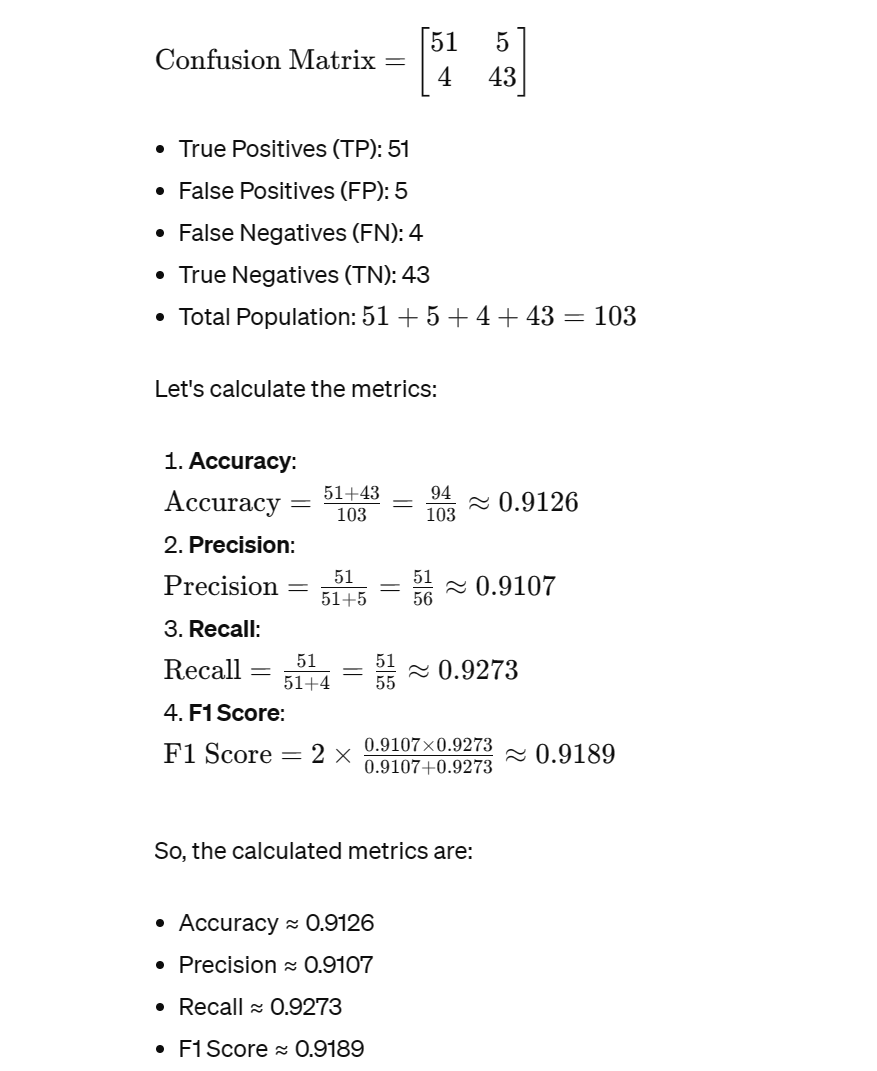

In [6]:
from sklearn.tree import DecisionTreeClassifier

# Initialize Decision Tree Classifier
dt_classifier = DecisionTreeClassifier(random_state=42)

# Train the classifier
dt_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_dt = dt_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_dt = accuracy_score(y_val_encoded, val_predictions_dt)
print("Validation Accuracy (Decision Tree Classifier):", val_accuracy_dt)

# Make predictions on test set
test_predictions_dt = dt_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_dt = accuracy_score(y_test_encoded, test_predictions_dt)
print("Test Accuracy (Decision Tree Classifier):", test_accuracy_dt)

# Calculate evaluation metrics for Decision Tree Classifier
val_precision_dt = precision_score(y_val_encoded, val_predictions_dt)
val_recall_dt = recall_score(y_val_encoded, val_predictions_dt)
val_f1_dt = f1_score(y_val_encoded, val_predictions_dt)
val_cm_dt = confusion_matrix(y_val_encoded, val_predictions_dt)

test_precision_dt = precision_score(y_test_encoded, test_predictions_dt)
test_recall_dt = recall_score(y_test_encoded, test_predictions_dt)
test_f1_dt = f1_score(y_test_encoded, test_predictions_dt)
test_cm_dt = confusion_matrix(y_test_encoded, test_predictions_dt)

# Print validation metrics for Decision Tree Classifier
print("\nValidation Metrics (Decision Tree Classifier):")
print("Precision:", val_precision_dt)
print("Recall:", val_recall_dt)
print("F1 Score:", val_f1_dt)
print("Confusion Matrix:")
print(val_cm_dt)

# Print classification report for Decision Tree Classifier on validation set
print("\nValidation Classification Report (Decision Tree Classifier):")
print(classification_report(y_val_encoded, val_predictions_dt, target_names=class_labels))

# Print test metrics for Decision Tree Classifier
print("\nTest Metrics (Decision Tree Classifier):")
print("Precision:", test_precision_dt)
print("Recall:", test_recall_dt)
print("F1 Score:", test_f1_dt)
print("Confusion Matrix:")
print(test_cm_dt)

# Print classification report for Decision Tree Classifier on test set
print("\nTest Classification Report (Decision Tree Classifier):")
print(classification_report(y_test_encoded, test_predictions_dt, target_names=class_labels))


Validation Accuracy (Decision Tree Classifier): 0.7438423645320197
Test Accuracy (Decision Tree Classifier): 0.6990291262135923

Validation Metrics (Decision Tree Classifier):
Precision: 0.6893203883495146
Recall: 0.7802197802197802
F1 Score: 0.7319587628865979
Confusion Matrix:
[[80 32]
 [20 71]]

Validation Classification Report (Decision Tree Classifier):
              precision    recall  f1-score   support

    Abnormal       0.80      0.71      0.75       112
      Normal       0.69      0.78      0.73        91

    accuracy                           0.74       203
   macro avg       0.74      0.75      0.74       203
weighted avg       0.75      0.74      0.74       203


Test Metrics (Decision Tree Classifier):
Precision: 0.6333333333333333
Recall: 0.8085106382978723
F1 Score: 0.7102803738317757
Confusion Matrix:
[[34 22]
 [ 9 38]]

Test Classification Report (Decision Tree Classifier):
              precision    recall  f1-score   support

    Abnormal       0.79      0.61   

In [7]:
#Accuracy ≈ 0.6990
#Precision ≈ 0.6071
#Recall ≈ 0.7907
#F1 Score ≈ 0.6876

In [8]:
from sklearn.neural_network import MLPClassifier

# Initialize MLP Classifier
mlp_classifier = MLPClassifier(hidden_layer_sizes=(100,), activation='relu', solver='adam', alpha=0.0001,random_state=42)

# Train the classifier
mlp_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_mlp = mlp_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_mlp = accuracy_score(y_val_encoded, val_predictions_mlp)
print("Validation Accuracy (MLP Classifier):", val_accuracy_mlp)

# Make predictions on test set
test_predictions_mlp = mlp_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_mlp = accuracy_score(y_test_encoded, test_predictions_mlp)
print("Test Accuracy (MLP Classifier):", test_accuracy_mlp)

# Calculate evaluation metrics for MLP Classifier
val_precision_mlp = precision_score(y_val_encoded, val_predictions_mlp)
val_recall_mlp = recall_score(y_val_encoded, val_predictions_mlp)
val_f1_mlp = f1_score(y_val_encoded, val_predictions_mlp)
val_cm_mlp = confusion_matrix(y_val_encoded, val_predictions_mlp)

test_precision_mlp = precision_score(y_test_encoded, test_predictions_mlp)
test_recall_mlp = recall_score(y_test_encoded, test_predictions_mlp)
test_f1_mlp = f1_score(y_test_encoded, test_predictions_mlp)
test_cm_mlp = confusion_matrix(y_test_encoded, test_predictions_mlp)

# Print validation metrics for MLP Classifier
print("\nValidation Metrics (MLP Classifier):")
print("Precision:", val_precision_mlp)
print("Recall:", val_recall_mlp)
print("F1 Score:", val_f1_mlp)
print("Confusion Matrix:")
print(val_cm_mlp)

# Print classification report for MLP Classifier on validation set
print("\nValidation Classification Report (MLP Classifier):")
print(classification_report(y_val_encoded, val_predictions_mlp, target_names=class_labels))

# Print test metrics for MLP Classifier
print("\nTest Metrics (MLP Classifier):")
print("Precision:", test_precision_mlp)
print("Recall:", test_recall_mlp)
print("F1 Score:", test_f1_mlp)
print("Confusion Matrix:")
print(test_cm_mlp)

# Print classification report for MLP Classifier on test set
print("\nTest Classification Report (MLP Classifier):")
print(classification_report(y_test_encoded, test_predictions_mlp, target_names=class_labels))


Validation Accuracy (MLP Classifier): 0.8768472906403941
Test Accuracy (MLP Classifier): 0.912621359223301

Validation Metrics (MLP Classifier):
Precision: 0.9024390243902439
Recall: 0.8131868131868132
F1 Score: 0.8554913294797688
Confusion Matrix:
[[104   8]
 [ 17  74]]

Validation Classification Report (MLP Classifier):
              precision    recall  f1-score   support

    Abnormal       0.86      0.93      0.89       112
      Normal       0.90      0.81      0.86        91

    accuracy                           0.88       203
   macro avg       0.88      0.87      0.87       203
weighted avg       0.88      0.88      0.88       203


Test Metrics (MLP Classifier):
Precision: 0.8958333333333334
Recall: 0.9148936170212766
F1 Score: 0.9052631578947369
Confusion Matrix:
[[51  5]
 [ 4 43]]

Test Classification Report (MLP Classifier):
              precision    recall  f1-score   support

    Abnormal       0.93      0.91      0.92        56
      Normal       0.90      0.91      

* Accuracy ≈ 0.9126
* Precision ≈ 0.8958
* Recall ≈ 0.9149
* F1 Score ≈ 0.9053


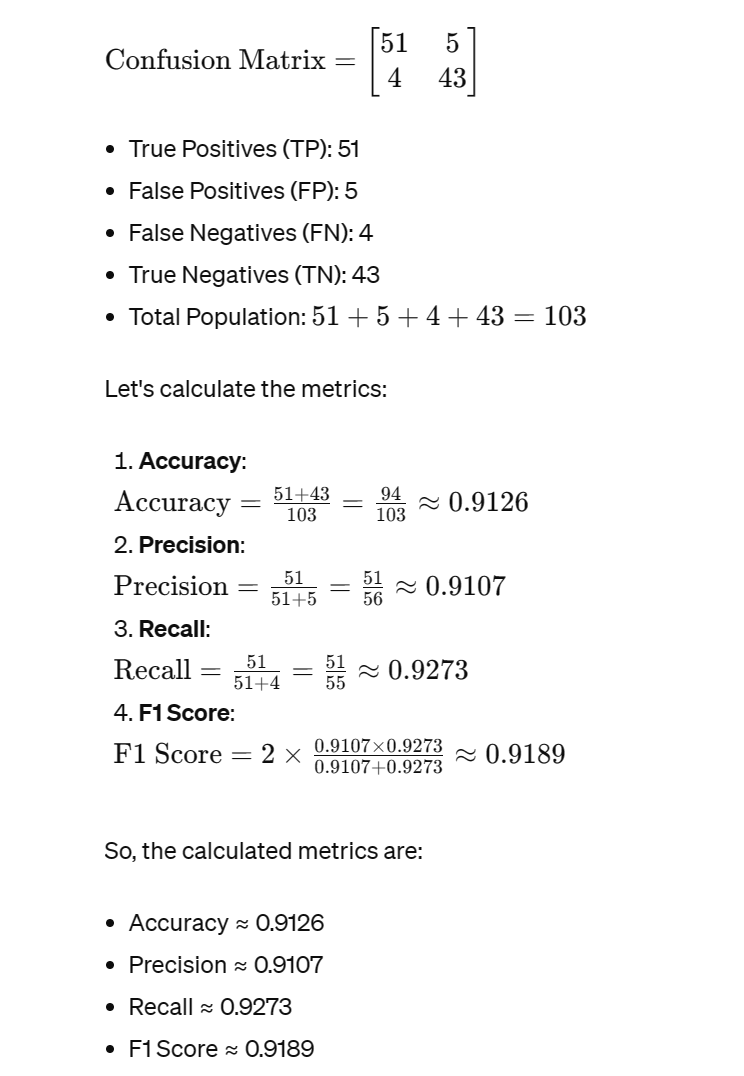

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Initialize Random Forest Classifier
rf_classifier = RandomForestClassifier(random_state=42)

# Train the classifier
rf_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_rf = rf_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_rf = accuracy_score(y_val_encoded, val_predictions_rf)
print("Validation Accuracy (Random Forest Classifier):", val_accuracy_rf)

# Make predictions on test set
test_predictions_rf = rf_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_rf = accuracy_score(y_test_encoded, test_predictions_rf)
print("Test Accuracy (Random Forest Classifier):", test_accuracy_rf)

# Calculate evaluation metrics for Random Forest Classifier
val_precision_rf = precision_score(y_val_encoded, val_predictions_rf)
val_recall_rf = recall_score(y_val_encoded, val_predictions_rf)
val_f1_rf = f1_score(y_val_encoded, val_predictions_rf)
val_cm_rf = confusion_matrix(y_val_encoded, val_predictions_rf)

test_precision_rf = precision_score(y_test_encoded, test_predictions_rf)
test_recall_rf = recall_score(y_test_encoded, test_predictions_rf)
test_f1_rf = f1_score(y_test_encoded, test_predictions_rf)
test_cm_rf = confusion_matrix(y_test_encoded, test_predictions_rf)

# Print validation metrics for Random Forest Classifier
print("\nValidation Metrics (Random Forest Classifier):")
print("Precision:", val_precision_rf)
print("Recall:", val_recall_rf)
print("F1 Score:", val_f1_rf)
print("Confusion Matrix:")
print(val_cm_rf)

# Print classification report for Random Forest Classifier on validation set
print("\nValidation Classification Report (Random Forest Classifier):")
print(classification_report(y_val_encoded, val_predictions_rf, target_names=class_labels))

# Print test metrics for Random Forest Classifier
print("\nTest Metrics (Random Forest Classifier):")
print("Precision:", test_precision_rf)
print("Recall:", test_recall_rf)
print("F1 Score:", test_f1_rf)
print("Confusion Matrix:")
print(test_cm_rf)

# Print classification report for Random Forest Classifier on test set
print("\nTest Classification Report (Random Forest Classifier):")
print(classification_report(y_test_encoded, test_predictions_rf, target_names=class_labels))


Validation Accuracy (Random Forest Classifier): 0.7093596059113301
Test Accuracy (Random Forest Classifier): 0.6893203883495146

Validation Metrics (Random Forest Classifier):
Precision: 1.0
Recall: 0.3516483516483517
F1 Score: 0.5203252032520326
Confusion Matrix:
[[112   0]
 [ 59  32]]

Validation Classification Report (Random Forest Classifier):
              precision    recall  f1-score   support

    Abnormal       0.65      1.00      0.79       112
      Normal       1.00      0.35      0.52        91

    accuracy                           0.71       203
   macro avg       0.83      0.68      0.66       203
weighted avg       0.81      0.71      0.67       203


Test Metrics (Random Forest Classifier):
Precision: 0.9411764705882353
Recall: 0.3404255319148936
F1 Score: 0.5
Confusion Matrix:
[[55  1]
 [31 16]]

Test Classification Report (Random Forest Classifier):
              precision    recall  f1-score   support

    Abnormal       0.64      0.98      0.77        56
      No

* Accuracy ≈ 0.6893
* Precision ≈ 0.9412
* Recall ≈ 0.3404
* F1 Score ≈ 0.5016

In [10]:
from sklearn.experimental import enable_hist_gradient_boosting  # Enable the experimental feature
from sklearn.ensemble import HistGradientBoostingClassifier

# Initialize HistGradientBoostingClassifier
hgbc_classifier = HistGradientBoostingClassifier(random_state=42)

# Train the classifier
hgbc_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_hgbc = hgbc_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_hgbc = accuracy_score(y_val_encoded, val_predictions_hgbc)
print("Validation Accuracy (HistGradientBoostingClassifier):", val_accuracy_hgbc)

# Make predictions on test set
test_predictions_hgbc = hgbc_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_hgbc = accuracy_score(y_test_encoded, test_predictions_hgbc)
print("Test Accuracy (HistGradientBoostingClassifier):", test_accuracy_hgbc)

# Calculate evaluation metrics for HistGradientBoostingClassifier
val_precision_hgbc = precision_score(y_val_encoded, val_predictions_hgbc)
val_recall_hgbc = recall_score(y_val_encoded, val_predictions_hgbc)
val_f1_hgbc = f1_score(y_val_encoded, val_predictions_hgbc)
val_cm_hgbc = confusion_matrix(y_val_encoded, val_predictions_hgbc)

test_precision_hgbc = precision_score(y_test_encoded, test_predictions_hgbc)
test_recall_hgbc = recall_score(y_test_encoded, test_predictions_hgbc)
test_f1_hgbc = f1_score(y_test_encoded, test_predictions_hgbc)
test_cm_hgbc = confusion_matrix(y_test_encoded, test_predictions_hgbc)

# Print validation metrics for HistGradientBoostingClassifier
print("\nValidation Metrics (HistGradientBoostingClassifier):")
print("Precision:", val_precision_hgbc)
print("Recall:", val_recall_hgbc)
print("F1 Score:", val_f1_hgbc)
print("Confusion Matrix:")
print(val_cm_hgbc)

# Print classification report for HistGradientBoostingClassifier on validation set
print("\nValidation Classification Report (HistGradientBoostingClassifier):")
print(classification_report(y_val_encoded, val_predictions_hgbc, target_names=class_labels))

# Print test metrics for HistGradientBoostingClassifier
print("\nTest Metrics (HistGradientBoostingClassifier):")
print("Precision:", test_precision_hgbc)
print("Recall:", test_recall_hgbc)
print("F1 Score:", test_f1_hgbc)
print("Confusion Matrix:")
print(test_cm_hgbc)

# Print classification report for HistGradientBoostingClassifier on test set
print("\nTest Classification Report (HistGradientBoostingClassifier):")
print(classification_report(y_test_encoded, test_predictions_hgbc, target_names=class_labels))


/opt/conda/lib/python3.10/site-packages/sklearn/experimental/enable_hist_gradient_boosting.py:16: UserWarning: Since version 1.0, it is not needed to import enable_hist_gradient_boosting anymore. HistGradientBoostingClassifier and HistGradientBoostingRegressor are now stable and can be normally imported from sklearn.ensemble.
  warnings.warn(


Validation Accuracy (HistGradientBoostingClassifier): 0.8817733990147784
Test Accuracy (HistGradientBoostingClassifier): 0.8737864077669902

Validation Metrics (HistGradientBoostingClassifier):
Precision: 0.819047619047619
Recall: 0.945054945054945
F1 Score: 0.8775510204081632
Confusion Matrix:
[[93 19]
 [ 5 86]]

Validation Classification Report (HistGradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.95      0.83      0.89       112
      Normal       0.82      0.95      0.88        91

    accuracy                           0.88       203
   macro avg       0.88      0.89      0.88       203
weighted avg       0.89      0.88      0.88       203


Test Metrics (HistGradientBoostingClassifier):
Precision: 0.7931034482758621
Recall: 0.9787234042553191
F1 Score: 0.8761904761904762
Confusion Matrix:
[[44 12]
 [ 1 46]]

Test Classification Report (HistGradientBoostingClassifier):
              precision    recall  f1-score   support

  

* Accuracy ≈ 0.8738
* Precision ≈ 0.7931
* Recall ≈ 0.9787
* F1 Score ≈ 0.8756

In [11]:
from sklearn.ensemble import GradientBoostingClassifier

# Initialize GradientBoostingClassifier
gb_classifier = GradientBoostingClassifier(random_state=42)

# Train the classifier
gb_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_gb = gb_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_gb = accuracy_score(y_val_encoded, val_predictions_gb)
print("Validation Accuracy (GradientBoostingClassifier):", val_accuracy_gb)

# Make predictions on test set
test_predictions_gb = gb_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_gb = accuracy_score(y_test_encoded, test_predictions_gb)
print("Test Accuracy (GradientBoostingClassifier):", test_accuracy_gb)

# Calculate evaluation metrics for GradientBoostingClassifier
val_precision_gb = precision_score(y_val_encoded, val_predictions_gb)
val_recall_gb = recall_score(y_val_encoded, val_predictions_gb)
val_f1_gb = f1_score(y_val_encoded, val_predictions_gb)
val_cm_gb = confusion_matrix(y_val_encoded, val_predictions_gb)

test_precision_gb = precision_score(y_test_encoded, test_predictions_gb)
test_recall_gb = recall_score(y_test_encoded, test_predictions_gb)
test_f1_gb = f1_score(y_test_encoded, test_predictions_gb)
test_cm_gb = confusion_matrix(y_test_encoded, test_predictions_gb)

# Print validation metrics for GradientBoostingClassifier
print("\nValidation Metrics (GradientBoostingClassifier):")
print("Precision:", val_precision_gb)
print("Recall:", val_recall_gb)
print("F1 Score:", val_f1_gb)
print("Confusion Matrix:")
print(val_cm_gb)

# Print classification report for GradientBoostingClassifier on validation set
print("\nValidation Classification Report (GradientBoostingClassifier):")
print(classification_report(y_val_encoded, val_predictions_gb, target_names=class_labels))

# Print test metrics for GradientBoostingClassifier
print("\nTest Metrics (GradientBoostingClassifier):")
print("Precision:", test_precision_gb)
print("Recall:", test_recall_gb)
print("F1 Score:", test_f1_gb)
print("Confusion Matrix:")
print(test_cm_gb)

# Print classification report for GradientBoostingClassifier on test set
print("\nTest Classification Report (GradientBoostingClassifier):")
print(classification_report(y_test_encoded, test_predictions_gb, target_names=class_labels))


Validation Accuracy (GradientBoostingClassifier): 0.8423645320197044
Test Accuracy (GradientBoostingClassifier): 0.8252427184466019

Validation Metrics (GradientBoostingClassifier):
Precision: 0.7920792079207921
Recall: 0.8791208791208791
F1 Score: 0.8333333333333334
Confusion Matrix:
[[91 21]
 [11 80]]

Validation Classification Report (GradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.89      0.81      0.85       112
      Normal       0.79      0.88      0.83        91

    accuracy                           0.84       203
   macro avg       0.84      0.85      0.84       203
weighted avg       0.85      0.84      0.84       203


Test Metrics (GradientBoostingClassifier):
Precision: 0.7543859649122807
Recall: 0.9148936170212766
F1 Score: 0.8269230769230769
Confusion Matrix:
[[42 14]
 [ 4 43]]

Test Classification Report (GradientBoostingClassifier):
              precision    recall  f1-score   support

    Abnormal       0.91 

* Accuracy ≈ 0.8252
* Precision ≈ 0.7544
* Recall ≈ 0.9149
* F1 Score ≈ 0.8276

In [12]:
from sklearn.ensemble import AdaBoostClassifier

# Initialize AdaBoostClassifier
adaboost_classifier = AdaBoostClassifier(random_state=42)

# Train the classifier
adaboost_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_adaboost = adaboost_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_adaboost = accuracy_score(y_val_encoded, val_predictions_adaboost)
print("Validation Accuracy (AdaBoostClassifier):", val_accuracy_adaboost)

# Make predictions on test set
test_predictions_adaboost = adaboost_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_adaboost = accuracy_score(y_test_encoded, test_predictions_adaboost)
print("Test Accuracy (AdaBoostClassifier):", test_accuracy_adaboost)

# Calculate evaluation metrics for AdaBoostClassifier
val_precision_adaboost = precision_score(y_val_encoded, val_predictions_adaboost)
val_recall_adaboost = recall_score(y_val_encoded, val_predictions_adaboost)
val_f1_adaboost = f1_score(y_val_encoded, val_predictions_adaboost)
val_cm_adaboost = confusion_matrix(y_val_encoded, val_predictions_adaboost)

test_precision_adaboost = precision_score(y_test_encoded, test_predictions_adaboost)
test_recall_adaboost = recall_score(y_test_encoded, test_predictions_adaboost)
test_f1_adaboost = f1_score(y_test_encoded, test_predictions_adaboost)
test_cm_adaboost = confusion_matrix(y_test_encoded, test_predictions_adaboost)

# Print validation metrics for AdaBoostClassifier
print("\nValidation Metrics (AdaBoostClassifier):")
print("Precision:", val_precision_adaboost)
print("Recall:", val_recall_adaboost)
print("F1 Score:", val_f1_adaboost)
print("Confusion Matrix:")
print(val_cm_adaboost)

# Print classification report for AdaBoostClassifier on validation set
print("\nValidation Classification Report (AdaBoostClassifier):")
print(classification_report(y_val_encoded, val_predictions_adaboost, target_names=class_labels))

# Print test metrics for AdaBoostClassifier
print("\nTest Metrics (AdaBoostClassifier):")
print("Precision:", test_precision_adaboost)
print("Recall:", test_recall_adaboost)
print("F1 Score:", test_f1_adaboost)
print("Confusion Matrix:")
print(test_cm_adaboost)

# Print classification report for AdaBoostClassifier on test set
print("\nTest Classification Report (AdaBoostClassifier):")
print(classification_report(y_test_encoded, test_predictions_adaboost, target_names=class_labels))


Validation Accuracy (AdaBoostClassifier): 0.7586206896551724
Test Accuracy (AdaBoostClassifier): 0.7087378640776699

Validation Metrics (AdaBoostClassifier):
Precision: 0.6666666666666666
Recall: 0.9230769230769231
F1 Score: 0.7741935483870968
Confusion Matrix:
[[70 42]
 [ 7 84]]

Validation Classification Report (AdaBoostClassifier):
              precision    recall  f1-score   support

    Abnormal       0.91      0.62      0.74       112
      Normal       0.67      0.92      0.77        91

    accuracy                           0.76       203
   macro avg       0.79      0.77      0.76       203
weighted avg       0.80      0.76      0.76       203


Test Metrics (AdaBoostClassifier):
Precision: 0.6268656716417911
Recall: 0.8936170212765957
F1 Score: 0.7368421052631579
Confusion Matrix:
[[31 25]
 [ 5 42]]

Test Classification Report (AdaBoostClassifier):
              precision    recall  f1-score   support

    Abnormal       0.86      0.55      0.67        56
      Normal      

In [13]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression Classifier
lr_classifier = LogisticRegression(random_state=42)

# Train the classifier
lr_classifier.fit(X_train_pca, y_train_encoded)  # X_train_pca or X_train_hog

# Make predictions on validation set
val_predictions_lr = lr_classifier.predict(X_val_pca)  # X_val_pca or X_val_hog

# Calculate accuracy on validation set
val_accuracy_lr = accuracy_score(y_val_encoded, val_predictions_lr)
print("Validation Accuracy (Logistic Regression):", val_accuracy_lr)

# Make predictions on test set
test_predictions_lr = lr_classifier.predict(X_test_pca)  # X_test_pca or X_test_hog

# Calculate accuracy on test set
test_accuracy_lr = accuracy_score(y_test_encoded, test_predictions_lr)
print("Test Accuracy (Logistic Regression):", test_accuracy_lr)

# Calculate evaluation metrics for Logistic Regression
val_precision_lr = precision_score(y_val_encoded, val_predictions_lr)
val_recall_lr = recall_score(y_val_encoded, val_predictions_lr)
val_f1_lr = f1_score(y_val_encoded, val_predictions_lr)
val_cm_lr = confusion_matrix(y_val_encoded, val_predictions_lr)

test_precision_lr = precision_score(y_test_encoded, test_predictions_lr)
test_recall_lr = recall_score(y_test_encoded, test_predictions_lr)
test_f1_lr = f1_score(y_test_encoded, test_predictions_lr)
test_cm_lr = confusion_matrix(y_test_encoded, test_predictions_lr)

# Print validation metrics for Logistic Regression
print("\nValidation Metrics (Logistic Regression):")
print("Precision:", val_precision_lr)
print("Recall:", val_recall_lr)
print("F1 Score:", val_f1_lr)
print("Confusion Matrix:")
print(val_cm_lr)

# Print classification report for Logistic Regression on validation set
print("\nValidation Classification Report (Logistic Regression):")
print(classification_report(y_val_encoded, val_predictions_lr, target_names=class_labels))

# Print test metrics for Logistic Regression
print("\nTest Metrics (Logistic Regression):")
print("Precision:", test_precision_lr)
print("Recall:", test_recall_lr)
print("F1 Score:", test_f1_lr)
print("Confusion Matrix:")
print(test_cm_lr)

# Print classification report for Logistic Regression on test set
print("\nTest Classification Report (Logistic Regression):")
print(classification_report(y_test_encoded, test_predictions_lr, target_names=class_labels))


Validation Accuracy (Logistic Regression): 0.9014778325123153
Test Accuracy (Logistic Regression): 0.9029126213592233

Validation Metrics (Logistic Regression):
Precision: 0.9382716049382716
Recall: 0.8351648351648352
F1 Score: 0.8837209302325583
Confusion Matrix:
[[107   5]
 [ 15  76]]

Validation Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    Abnormal       0.88      0.96      0.91       112
      Normal       0.94      0.84      0.88        91

    accuracy                           0.90       203
   macro avg       0.91      0.90      0.90       203
weighted avg       0.90      0.90      0.90       203


Test Metrics (Logistic Regression):
Precision: 0.8936170212765957
Recall: 0.8936170212765957
F1 Score: 0.8936170212765957
Confusion Matrix:
[[51  5]
 [ 5 42]]

Test Classification Report (Logistic Regression):
              precision    recall  f1-score   support

    Abnormal       0.91      0.91      0.91        56
      No

* Accuracy ≈ 0.9029
* Precision ≈ 0.8936
* Recall ≈ 0.8936
* F1 Score ≈ 0.8936

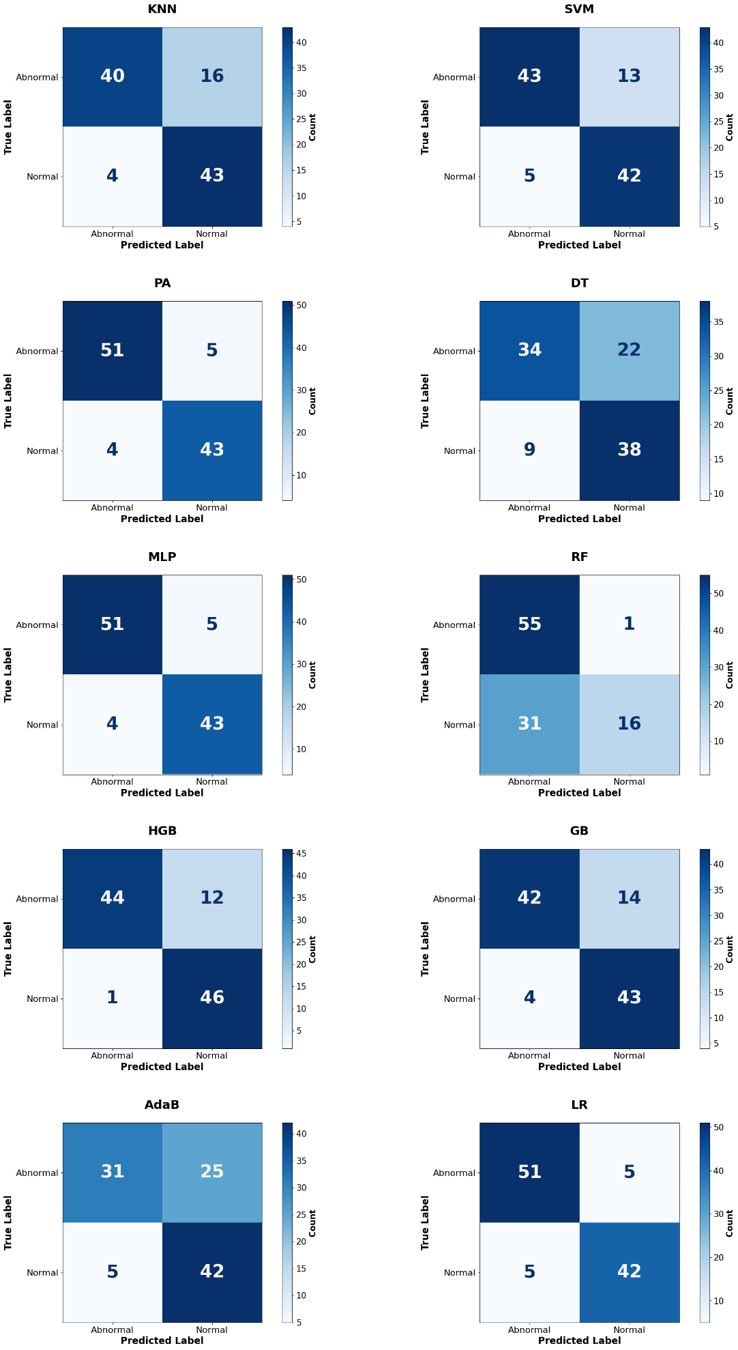